# AI knit swatch preview

Structured input (stitch, colour hex, weight, fibre) → prompt → image, with a content-hash cache, a placeholder fallback, a Ravelry reference photo and a fast tint path for colour switching.

Cells follow the video order. **Run: Kernel → Restart & Run All** from `assignment-b/`.
With no `OPENAI_API_KEY` the notebook still runs: the provider becomes `offline`, which serves the committed example images from `cache/` and shows the placeholder for anything else.
Log lines (`SWATCH …`, `RAVELRY …`) are printed under each cell.

In [1]:
import io
import logging
from pathlib import Path

from dotenv import load_dotenv
from IPython.display import Image as JpegImage
from IPython.display import Markdown, display
from PIL import Image, ImageDraw

load_dotenv(Path.cwd().parent / ".env")
logging.basicConfig(level=logging.WARNING, format="%(message)s", force=True)
logging.getLogger("swatch").setLevel(logging.INFO)

from swatch import cost, ravelry
from swatch.cache import SwatchCache
from swatch.config import CONFIG
from swatch.pipeline import get_swatch, get_swatch_fast, key_for
from swatch.providers import FailingProvider, get_image_provider

provider = get_image_provider()
cache = SwatchCache()
print(f"provider={provider.name} model={provider.model} quality={getattr(provider, 'quality', '-')}")

BRIEF = {"stitch_type": "cable", "colour_name": "royal purple", "colour_hex": "#5B3E96",
         "weight_category": "worsted", "fibre_content": "100% wool"}
PRESETS = {p.name: p.hex for p in CONFIG.presets.items}


def caption(r):
    ms = f"{r.elapsed_ms:,.0f} ms"
    if r.source == "cache":
        ms += f" (generated in {r.generation_ms:,.0f} ms)"
    return [f"{r.inputs.stitch_type} {r.inputs.colour_hex}", f"source={r.source}  {ms}", f"dE={r.delta_e:.1f}" + (" (tinted)" if r.tinted else "")]


def show(images, captions, size=300):
    """Images side by side with a caption block under each."""
    pad = 18 * max(len(c) for c in captions) + 8
    sheet = Image.new("RGB", (size * len(images) + 10 * (len(images) - 1), size + pad), "white")
    draw = ImageDraw.Draw(sheet)
    for i, (img, lines) in enumerate(zip(images, captions)):
        x = i * (size + 10)
        sheet.paste(img.resize((size, size)), (x, 0))
        for j, line in enumerate(lines):
            draw.text((x + 4, size + 4 + 18 * j), line, fill="black", font_size=14)
    buf = io.BytesIO()
    sheet.save(buf, "JPEG", quality=85)
    display(JpegImage(data=buf.getvalue(), format="jpeg"))


def show_results(results):
    show([r.image for r in results], [caption(r) for r in results])

SWATCH provider=openai model=gpt-image-1-mini


provider=openai model=gpt-image-1-mini quality=low


## 1. Generate one swatch (brief §4.2 example) → cache MISS
`FRESH = True` deletes this one cache entry first, so the MISS below is a real API call.

SWATCH cache=MISS key=c18d4c77b5… provider=openai elapsed_ms=10446 delta_e=9.8


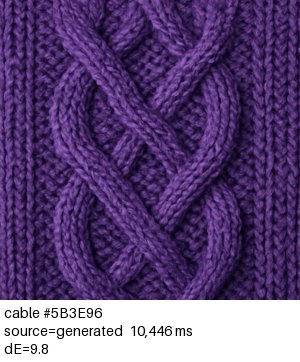

A close-up of cable knit fabric with thick twisted rope-like braids, plaited columns crossing over each other with deep shadows, raised 3D relief against a flat purl background. The yarn colour is exactly #5B3E96, RGB(91, 62, 150), a medium muted purple colour, evenly dyed, solid single colour. The swatch is made with worsted-weight yarn, medium-sized clearly defined stitches, wool yarn with visible ply twist and a slight matte fuzz. Top-down macro photograph of a flat 10 by 10 centimetre hand-knitted swatch filling the entire frame, even soft studio lighting, sharp focus, photorealistic, no hands, no needles, no text, no border, no other colours.


In [2]:
FRESH = True  # only takes effect with a real provider; offline runs keep the committed image
if FRESH and provider.name == "openai":
    cache.delete(key_for(BRIEF, provider))
first = get_swatch(BRIEF, provider=provider, cache=cache)
show_results([first])
print(first.prompt)

## 2. Exactly the same call again → cache HIT, no API call

SWATCH cache=HIT key=c18d4c77b5… elapsed_ms=6


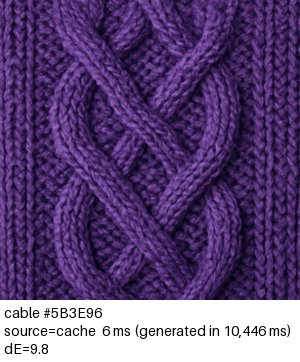

same key: True   provider calls made by this cell: 0


In [3]:
calls_before = provider.calls
again = get_swatch(BRIEF, provider=provider, cache=cache)
show_results([again])
print(f"same key: {again.key == first.key}   provider calls made by this cell: {provider.calls - calls_before}")

## 3. One stitch, three colours (colour switching)

SWATCH cache=HIT key=c18d4c77b5… elapsed_ms=6


SWATCH cache=MISS key=c0e083d464… provider=openai elapsed_ms=10025 delta_e=14.8 tinted->0.3


SWATCH cache=MISS key=240cefba12… provider=openai elapsed_ms=9164 delta_e=9.8


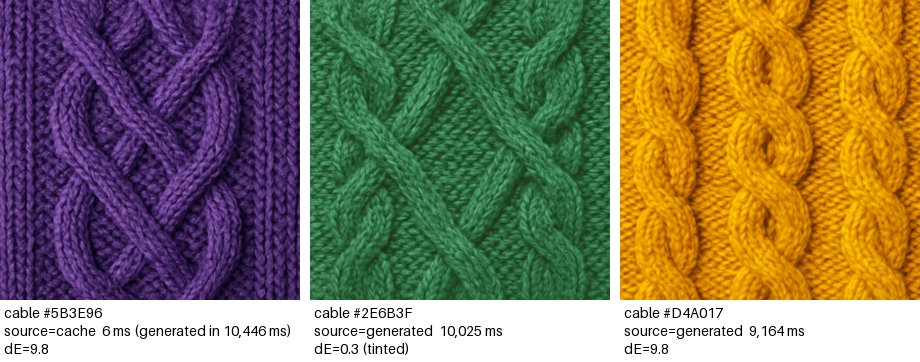

royal purple  generation  10,446 ms   dE raw 9.8 -> 9.8
forest green  generation  10,025 ms   dE raw 14.8 -> 0.3
mustard       generation   9,164 ms   dE raw 9.8 -> 9.8


In [4]:
colour_names = ["royal purple", "forest green", "mustard"]
by_colour = [get_swatch({**BRIEF, "colour_name": n, "colour_hex": PRESETS[n]}, provider=provider, cache=cache)
             for n in colour_names]
show_results(by_colour)
for r in by_colour:
    if r.source == "fallback":
        print(f"{r.inputs.colour_name:<13} placeholder (not cached offline)")
    else:
        print(f"{r.inputs.colour_name:<13} generation {r.generation_ms:>7,.0f} ms   dE raw {r.delta_e_raw:.1f} -> {r.delta_e:.1f}")

**How this felt.** Each fresh generation took about 10–14 s at `quality=low` (times above). Tapping a colour and waiting that long breaks the calm "flow" the product is built around, and six presets per stitch would be over a minute of generation. So fresh generation can't sit behind a colour tap: common combinations have to be pre-generated and cached (cell 2 shows a hit is milliseconds), and anything else needs the structure-once-then-tint path in cell 8, with the placeholder shown immediately. Details in `LATENCY_NOTE.md`.

## 4. One colour, three stitches (structure must differ)

SWATCH cache=MISS key=3d88c5e407… provider=openai elapsed_ms=11185 delta_e=8.2


SWATCH cache=HIT key=c18d4c77b5… elapsed_ms=8


SWATCH cache=MISS key=135034e480… provider=openai elapsed_ms=16643 delta_e=7.6


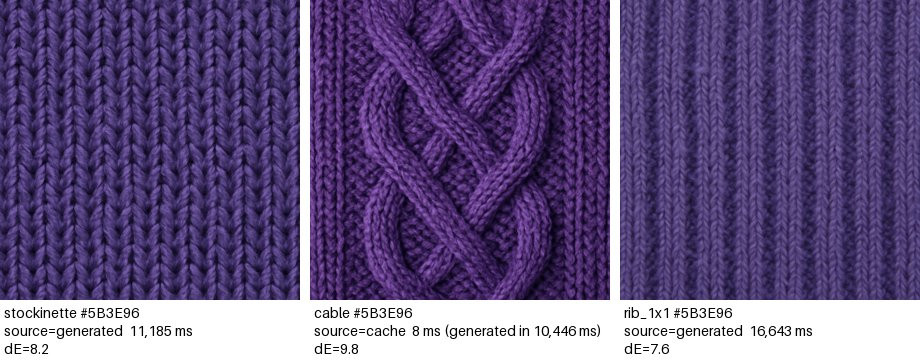

In [5]:
by_stitch = [get_swatch({**BRIEF, "stitch_type": s}, provider=provider, cache=cache)
             for s in ["stockinette", "cable", "rib_1x1"]]
show_results(by_stitch)

## 5. Generation fails → placeholder in the target colour
`FailingProvider` simulates an outage (the same happens with `SIMULATE_IMAGE_FAILURE=1` or an invalid key). The pipeline returns the stitch's procedural placeholder in the requested hex instead of crashing, and does not cache it, so the next call can succeed.

SWATCH fallback=placeholder reason='simulated outage (401 invalid API key)' provider=failing elapsed_ms=47


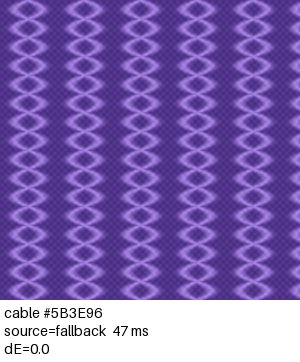

source=fallback error='simulated outage (401 invalid API key)'


In [6]:
failed = get_swatch(BRIEF, provider=FailingProvider(), cache=cache)
show_results([failed])
print(f"source={failed.source} error={failed.error!r}")

## 6. Ravelry reference photo next to the generated swatch
Pattern search on the stitch keyword (a loose match is fine per the brief); the first result with a photo is shown.

RAVELRY status=match query='cable' pattern='Cable Crew Family Set' elapsed_ms=880


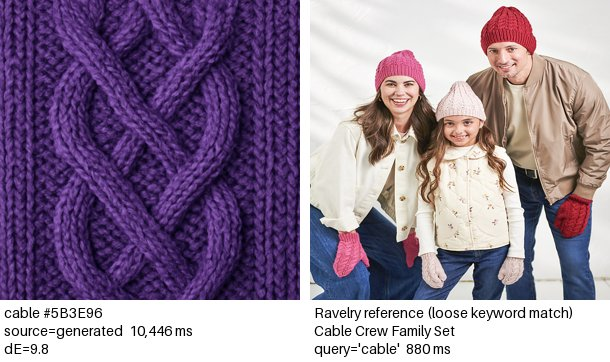

In [7]:
ref = ravelry.reference_for_stitch("cable")
photo = ravelry.fetch_photo(ref) if ref else None
if photo:
    show([first.image, photo], [caption(first), ["Ravelry reference (loose keyword match)", ref.pattern_name[:36], f"query={ref.query!r}  {ref.elapsed_ms:.0f} ms"]])
else:
    show_results([first])
    print("no reference found — showing the generated swatch on its own")

## 7. Ravelry no match, and a timeout → generated swatch on its own

RAVELRY status=no_match query='zzqx brioche teapot' results=0 elapsed_ms=662


no match: reference=None


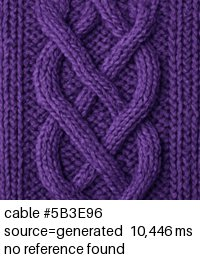

RAVELRY status=timeout query='cable' timeout_s=0.001


timeout: reference=None


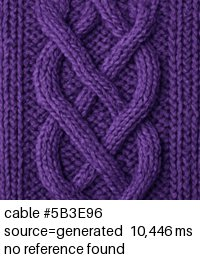

In [8]:
for label, kwargs in [("no match", {"query": "zzqx brioche teapot"}), ("timeout", {"query": "cable", "timeout_s": 0.001})]:
    ref = ravelry.search_reference(**kwargs)
    print(f"{label}: reference={ref}")
    if ref is None:
        show([first.image], [caption(first)[:2] + ["no reference found"]], size=200)

## 8. Faster colour switching: generate the structure once, then tint
One neutral-grey master per stitch/weight/fibre is generated (and cached). Each colour is then a LAB shift of the master that keeps the texture and takes milliseconds. "switch ms" is the whole call: master lookup plus tint. The first colour pays once for generating the master; every later colour is a cache hit plus a tint. Bottom row: fresh generations from cell 3 for comparison.

SWATCH cache=MISS key=735bd8066d… provider=openai elapsed_ms=10129 delta_e=14.0


SWATCH tint key=735bd8066d… master=generated tint_ms=265 elapsed_ms=10448 delta_e=0.5


SWATCH cache=HIT key=735bd8066d… elapsed_ms=6


SWATCH tint key=735bd8066d… master=cache tint_ms=55 elapsed_ms=61 delta_e=0.4


SWATCH cache=HIT key=735bd8066d… elapsed_ms=6


...

SWATCH tint key=735bd8066d… master=cache tint_ms=54 elapsed_ms=60 delta_e=0.5


SWATCH cache=HIT key=735bd8066d… elapsed_ms=6


SWATCH tint key=735bd8066d… master=cache tint_ms=53 elapsed_ms=59 delta_e=0.4


SWATCH cache=HIT key=735bd8066d… elapsed_ms=6


SWATCH tint key=735bd8066d… master=cache tint_ms=55 elapsed_ms=61 delta_e=0.3


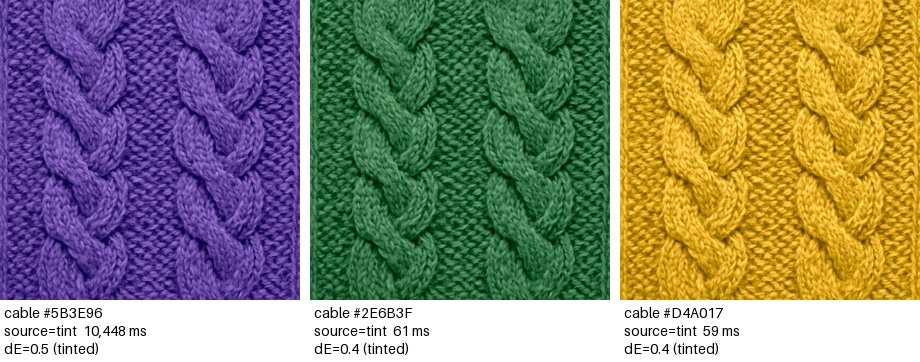

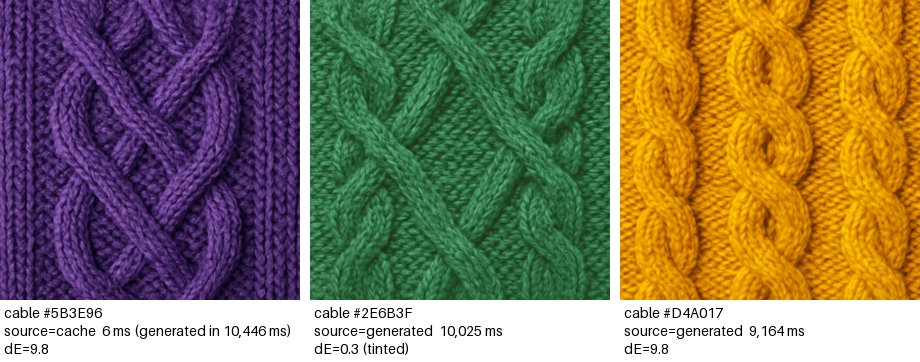

colour        switch ms  tint dE  generated ms  generated dE
royal purple    10448.4      0.5        10,446           9.8
forest green       61.3      0.4        10,025           0.3
mustard            58.6      0.4         9,164           9.8
brick red          60.2      0.5             -             -
denim blue         58.9      0.4             -             -
oatmeal            61.1      0.3             -             -


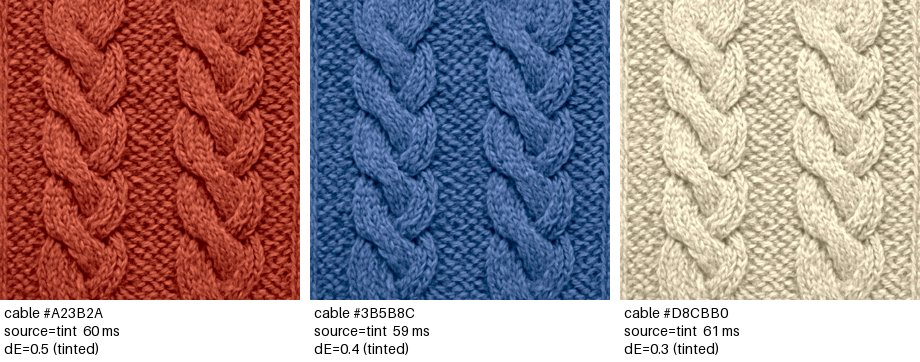

In [9]:
tinted = [get_swatch_fast({**BRIEF, "colour_name": n, "colour_hex": h}, provider=provider, cache=cache)
          for n, h in PRESETS.items()]
show_results(tinted[:3])
show_results(by_colour)

print(f"{'colour':<13} {'switch ms':>9} {'tint dE':>8} {'generated ms':>13} {'generated dE':>13}")
generated = {r.inputs.colour_hex: r for r in by_colour}
for r in tinted:
    g = generated.get(r.inputs.colour_hex)
    gen = f"{g.generation_ms:>13,.0f} {g.delta_e:>13.1f}" if g and g.generation_ms else f"{'-':>13} {'-':>13}"
    print(f"{r.inputs.colour_name:<13} {r.elapsed_ms:>9.1f} {r.delta_e:>8.1f} {gen}")
show_results(tinted[3:])

## 9. Cost estimate (2,000 previews/day)
Measured tokens for one generated image × OpenAI's published token prices (`config.yaml → cost`).

In [10]:
hit = cache.get(first.key)
meta = hit[1] if hit else {"model": CONFIG.image.default_model, "quality": CONFIG.image.quality, "usage": None}
tokens = CONFIG.cost.estimate_tokens
usage = meta["usage"] or {"input_tokens": tokens["input"], "output_tokens": tokens["output"]}
masters = len(CONFIG.stitches.items) * len(CONFIG.weights.items) * (len(CONFIG.fibres.items) + 1)
model = meta["model"] if meta["model"] in CONFIG.cost.token_prices_per_1m else CONFIG.image.default_model
lines = cost.monthly_estimate(model, usage["input_tokens"], usage["output_tokens"], masters)

rows = "\n".join(f"| {l.scenario} | {l.generations_per_month:,.0f} | ${l.usd_per_image:.4f} | ${l.usd_per_month:,.2f} |" for l in lines)
price = CONFIG.cost.token_prices_per_1m[model]
display(Markdown(f"""
Model **{model}**, quality **{meta['quality']}**: {usage['input_tokens']} prompt tokens + {usage['output_tokens']} image tokens per image.
Price: ${price['text_input']}/1M text in, ${price['image_output']}/1M image out ({CONFIG.cost.price_source}, checked {CONFIG.cost.prices_checked}).
Per image = {usage['input_tokens']} × {price['text_input']}/1M + {usage['output_tokens']} × {price['image_output']}/1M = **${lines[0].usd_per_image:.4f}**.
Volume = {CONFIG.cost.previews_per_day:,} previews/day × {CONFIG.cost.days_per_month} days.

| scenario | generations / month | $ / image | $ / month |
|---|---|---|---|
{rows}

The tint path pays once for {masters} grey masters ({len(CONFIG.stitches.items)} stitches × {len(CONFIG.weights.items)} weights × {len(CONFIG.fibres.items) + 1} fibre looks); that is a one-off, not a monthly cost.
"""))


Model **gpt-image-1-mini**, quality **low**: 162 prompt tokens + 272 image tokens per image.
Price: $2.0/1M text in, $8.0/1M image out (https://developers.openai.com/api/docs/pricing (Image Generation Models - Standard, USD per 1M tokens), checked 2026-09-17).
Per image = 162 × 2.0/1M + 272 × 8.0/1M = **$0.0025**.
Volume = 2,000 previews/day × 30 days.

| scenario | generations / month | $ / image | $ / month |
|---|---|---|---|
| no cache | 60,000 | $0.0025 | $150.00 |
| cache (60% hits) | 24,000 | $0.0025 | $60.00 |
| structure once + tint (392 masters) | 392 | $0.0025 | $0.98 |

The tint path pays once for 392 grey masters (7 stitches × 8 weights × 7 fibre looks); that is a one-off, not a monthly cost.


## Bonus: cache warming
`python warm_cache.py --stitches cable rib_1x1 --presets 3` pre-generates a fixed stitch × preset grid so the first user tap is already a cache hit (`--dry-run` lists the grid and the estimated cost without calling the API).